In [1]:
from numba import jit, njit
import kwant
from kwant.digest import uniform    # a (deterministic) pseudorandom number generator
import kwant.kpm


import scipy

import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

from scipy.ndimage import gaussian_filter


import cmath

from qutip import *
from joblib import Parallel, delayed

/opt/anaconda3/lib/python3.12/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "


In [2]:
def corr_dis(L, W, a, xic):
    Nx = int(L/a)
    Ny = int(W/a)
    Vxy = np.random.normal(0, 1., size=(Ny, Nx))/(a) + 1j*0.0
    
    kkVxy = np.fft.fft2(Vxy)
    kx = 2*np.pi * np.fft.fftfreq(kkVxy.shape[1],d=a)
    ky = 2*np.pi * np.fft.fftfreq(kkVxy.shape[0],d=a)
    kx, ky = np.meshgrid(kx,ky)
    
    kVxy = np.multiply(kkVxy, np.exp( - .125 * xic**2. * (kx**2.+ky**2.)  ) ) * xic/np.sqrt(2.)
    
    Vxy = np.fft.ifft2(kVxy)
    Vxy = Vxy - np.sum(Vxy)/(1.*Nx*Ny)

    return Vxy

In [3]:
def v_img_singleside(W, N, min_l):
    arr_x = np.linspace(min_l, W+min_l, N)
    arr_V = - 1./(np.abs( np.flip(arr_x) ))
    return arr_V


def v_img(W, N, min_l):
    arr_V = []
    arr_x = np.linspace(-W/2, W/2, N)
    d = 1000*W + 2*min_l
    for x in arr_x:
        V = 0
        nf = 50000
        n_Z = np.linspace( -nf, nf, 2*nf+1)
        for n in n_Z:
            if n != 0:
                V += ( 1./(2*np.abs(n)) - 1./(2.*np.abs(n+500*(x)/d )) )
        if x < 0:
            arr_V.append(V)
        else:
            arr_V.append(V)
    return np.asarray(arr_V)/d*1000


def v_expcutoff_img_singleside(W, N, min_l, xiV):
    arr_x = np.linspace(min_l, W+min_l, N)
    arr_V = - 1./(np.abs( np.flip(arr_x) ))*np.exp( -(np.abs((np.flip(arr_x-0*min_l)))/xiV)**1/(2) )
    #arr_V = - 1./(np.abs( arr_x )) /( np.exp( (arr_x-min_l - xiV)/(.01*xiV) ) + 1 )
    return arr_V

def fourth_conf(L, W):
    Vxy = np.zeros(shape=(W, L), dtype=np.complex_)
    xvec = np.linspace(0, W-1, int(W) )
    yvec = np.linspace(0, L-1, int(L) )    
    for nx in range(W):
        for ny in range(L): 
            Vxy[nx][ny] = 16*( xvec[nx]/W - 1/2. )**4
    return Vxy

def tan_confinement(L, W, dr, Wedge, A):
    Vxy = np.zeros(shape=(W, L), dtype=np.complex_)
    Nedge = int(Wedge/dr)
    xvec = np.linspace(0, W-1, int(W) )
    yvec = np.linspace(0, L-1, int(L) )    
    
    
    minRx = np.amin(xvec)
    maxRx = np.amax(xvec)
    for nx in range(W):
        for ny in range(L):
            if xvec[nx] <= (Wedge + minRx):
                Vxy[nx][ny] = (np.tan(A * np.pi/2.*( xvec[nx] - (Wedge + minRx) )/Wedge  ) )**2.
            elif xvec[nx] >= (maxRx-(Wedge)):
                Vxy[nx][ny] = (np.tan(A * np.pi/2.*( xvec[nx] - (maxRx-(Wedge) + dr/2.  ) )/Wedge  ) )**2.
    
    return np.sqrt(Vxy)

In [4]:

# Energy-Length-Magnetic scale (arbitrary) just to have a dimensional reference for the parameters
#a=0.6 # real lattice spacing in GaAs, in nm
#BandW0 = 40   #total bandwidth in meV
#l0 = np.sqrt(568/BandW0*8.) * 10**(-3.) # effective lattice spacing sqrt( \hbar^2/(2m*)/(\hbar J)) here I took \hbar^2/(2m*) = 568 nm^2 meV (GaAs) and \hbar J = BW/8 in micron!
#B0 = 4.14*10**3. / (l0 * 10**3.)**2. #in T, as 2\pi \hbar/e 1/a^2


lat = kwant.lattice.square(a=1, norbs=1)
iter_dis = 1
t = 1   # hopping rate for kwant
W = 120  # spatial width of the system ( Nx )
L = 120  # spatial length of the system ( Ny )

alpha = 1/30
lB = 1./np.sqrt(2*np.pi*alpha)
omB = 4*np.pi*alpha

Nelect = 5*alpha*(W-1)*(L-1)



xic = lB * 2.      # Correlation length and definition of disorder-potential array
Vdis = corr_dis(int(L), int(W), 1, xic)
plate_distance = 10*lB      #edge-plate distance
Vimg = v_img_singleside(W, int(W), plate_distance)   # normalized image potential single plate
#Vimg = v_expcutoff_img_singleside(W, int(W), plate_distance, 6*lB)
V_img_min = np.amin(Vimg)
Vimg = Vimg - V_img_min - lB/plate_distance**2 
#E_img = omB*lB * ( (plate_distance/lB)**2 ) / 3.         # Image charge amplitude in Zeeman
E_img = omB*lB * 0
E_dis = omB * .12                # disorder amplitude in cyclotrons


#Vconf = fourth_conf(L, W) * 1.3*omB
Vconf = tan_confinement(L, W, 1, int(W/7), .5)

def onsite(site, params):
    xi, yi = site.pos

    om0 = 4 * t  # Original onsite energy
    omRan = params.E_dis * params.V[int(xi)][int(yi)]  # Disorder
    omConf = params.Vconf[int(xi)][int(yi)]
    omImg = params.E_img * Vimg[int(xi)]  # Image charge

    return om0 + omRan + omImg + omConf

def hopping(site_i, site_j, params):
    xi, yi = site_i.pos
    xj, yj = site_j.pos

    phase = -1j * 2 * np.pi * params.alpha * (xi - xj) * (yi + yj) / 2.
    #phase = -1j * 2 * np.pi * params.alpha * (xi + xj) * (yi - yj) / 2.
    
    return -t * np.exp(phase)

def onsite_lead(site, params):
    return 4 * t

def hopping_lead(site_i, site_j, params):
    return -t 

sys = kwant.Builder()
#sym_y = kwant.TranslationalSymmetry((0, L))
#sys = kwant.Builder(sym_y)

sys[(lat(x, y) for x in range(W) for y in range(L))] = onsite
sys[lat.neighbors()] = hopping


for x in range(W): # PBC along y
    sys[lat(x, 0), lat(x, L-1)] = hopping  # connect top <-> bottom
    
#for y in range(L): # PBC along x
#    sys[lat(0, y), lat(W-1, y)] = hopping  # connect top <-> bottom


#kwant.wraparound.wraparound(sys, keep=(0,))

sys = sys.finalized()



params =SimpleNamespace( alpha=alpha, E_dis=E_dis, E_img=0, V=Vdis, Vimg=Vimg, Vconf=Vconf )
params_img = SimpleNamespace( alpha=alpha, E_dis=E_dis, E_img=E_img, V=Vdis, Vimg=Vimg, Vconf=Vconf )

ham_mat = sys.hamiltonian_submatrix( sparse=True, args=[params])


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_58387/3442234142.py:86: KwantDeprecationWarning: The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.
  ham_mat = sys.hamiltonian_submatrix( sparse=True, args=[params])


(0.9999999999999999+0j)


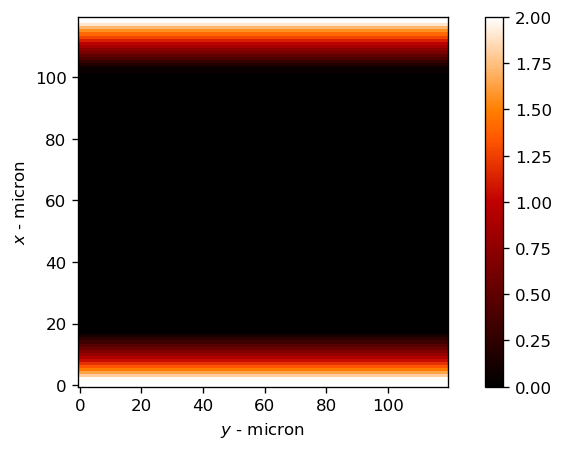

In [5]:
xvec = np.linspace(0, W-1, int(W) )
yvec = np.linspace(0, L-1, int(L) )
X, Y = np.meshgrid(yvec, xvec)

fig_conf, ax_conf = plt.subplots(dpi=120, figsize=(8, 4))

vmin = 0.
vmax = 2.000
conf_plot = ax_conf.pcolormesh(X*1, Y*1, (Vconf.real/omB), cmap='gist_heat', alpha=1, vmin=vmin, vmax=vmax)

fig_conf.colorbar(conf_plot)

ax_conf.set_xlabel(r'$y$ - micron')
ax_conf.set_ylabel(r'$x$ - micron')
ax_conf.set_aspect('equal')
print(np.amax(Vconf) )

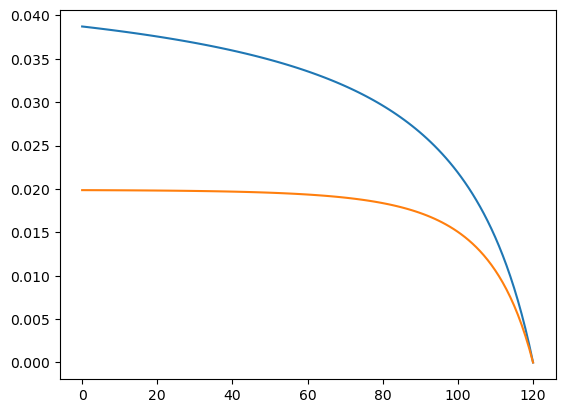

In [6]:
VII = v_img_singleside(W, int(W), 10*lB)
VIIex = v_expcutoff_img_singleside(W, int(W), 10*lB, 6*lB)
plt.plot(np.linspace(0, W, W), VII-np.amin(VII))
plt.plot(np.linspace(0, W, W), VIIex-np.amin(VIIex))

In [7]:
ham_mat.shape

(14400, 14400)

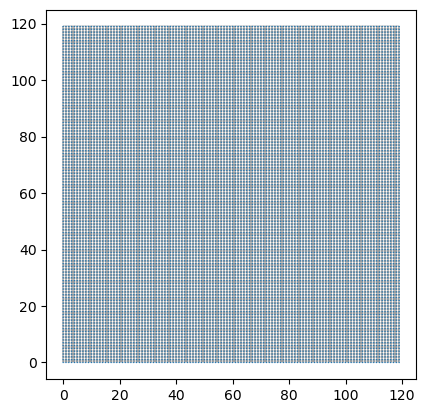

In [8]:
kwant.plot(sys);

In [9]:
import scipy.linalg

ham_dense = ham_mat.toarray()
#evals, evecs = np.linalg.eig(ham_dense)
evals, evecs = scipy.sparse.linalg.eigs(ham_mat.tocsc(), k=1000, sigma=0)



In [10]:

idx = np.argsort(evals)
evals = evals[idx]
evecs = evecs[:,idx]

In [11]:
positions = np.array([site.pos for site in sys.sites])
x_coords = positions[:, 0]

# Repeat each coordinate for the spin degrees of freedom
num_spin = 1
x_coords_spinful = np.repeat(x_coords, num_spin)

# Compute <x> for each eigenstate
x_avg = np.sum(np.abs(evecs)**2 * x_coords[:, np.newaxis], axis=0)

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning:

Casting complex values to real discards the imaginary part

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/collections.py:194: ComplexWarning:

Casting complex values to real discards the imaginary part



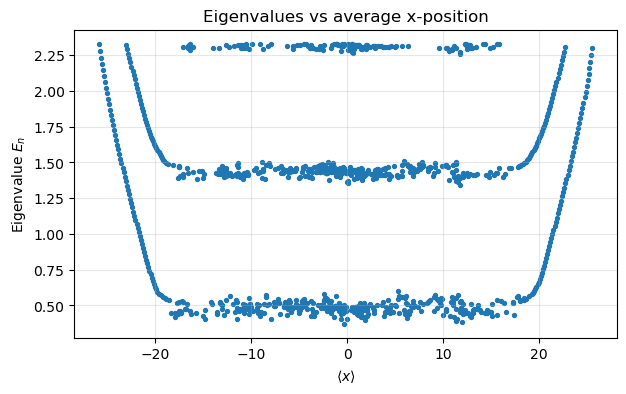

In [12]:
plt.figure(figsize=(7,4))
plt.scatter((x_avg-W/2)/lB, evals/omB, s=8)
plt.xlabel(r'$\langle x \rangle$')
plt.ylabel('Eigenvalue $E_n$')
plt.title('Eigenvalues vs average x-position')
plt.grid(True, alpha=0.3)
#plt.xlim(0,23)
plt.show()

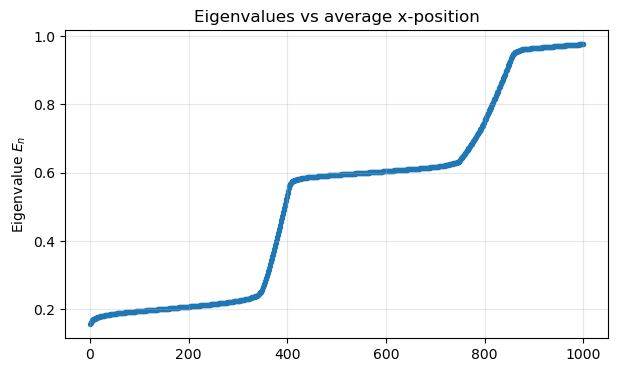

In [13]:
plt.figure(figsize=(7,4))
plt.scatter(np.linspace(0, len(evals), len(evals)), evals, s=8)
plt.ylabel('Eigenvalue $E_n$')
plt.title('Eigenvalues vs average x-position')
plt.grid(True, alpha=0.3)
plt.show()

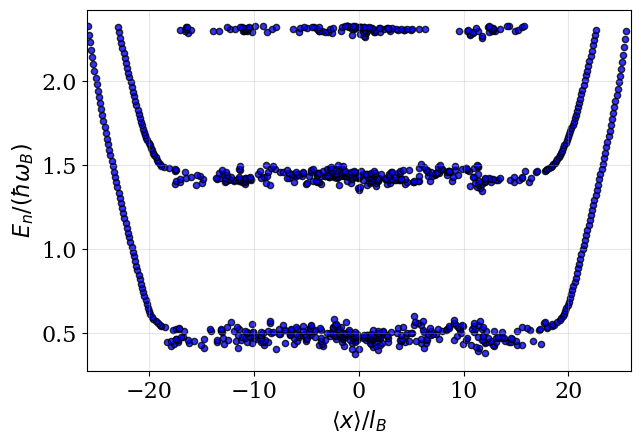

In [14]:

# --- Re-use your style settings ---
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

# --- Your existing data (example variables) ---
# x_avg, evals, W, lB, omB must be defined as before

# --- Create the styled plot ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter((x_avg - W/2)/lB, evals/omB,
           s=20,                # marker size
           color='blue',         # match main-figure palette
           edgecolor='black',   # thin border for clarity
           alpha=0.8)

ax.set_xlabel(r'$\langle x \rangle / l_B$', fontdict=font)
ax.set_ylabel(r'$E_n / (\hbar \omega_B)$', fontdict=font)
#ax.set_title('Eigenvalues vs average x-position', fontdict=font, pad=10)

# Match grid and limits style
ax.grid(True, alpha=0.3)
ax.set_xlim(-26, 26)

# Optional: match paper figure width (≈170 mm)
fig.set_size_inches(170 / 25.4, 120 / 25.4)
plt.tight_layout()

#plt.savefig('spec_cazzillo_scheme.pdf')
plt.show()

In [15]:
xi = np.zeros(len(evals))
for n in range(len(evals)):
    xi[n] = 1./( np.sum( np.abs(evecs[:,n])**4 ) )**.5

In [16]:
ntarg1 = 40
ntarg2 = 170
ntarg3 = 380

ntarg1 = 569
ntarg2 = 721
ntarg3 = 805

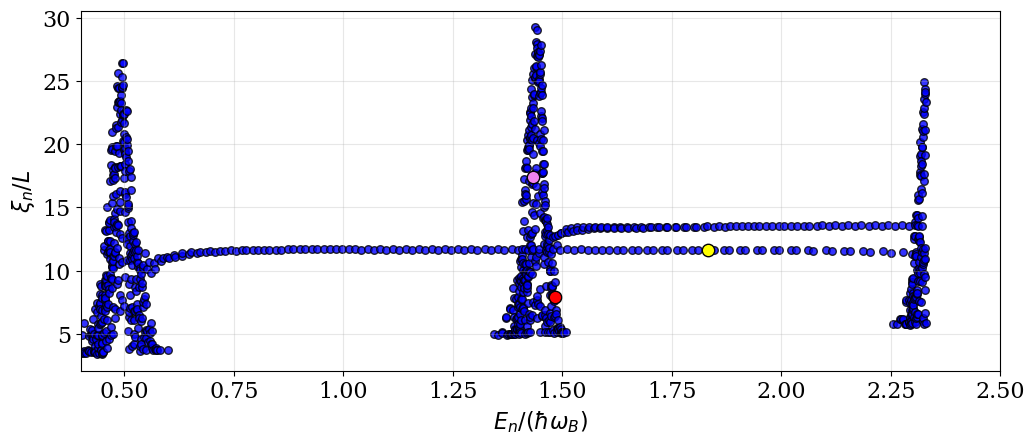

In [17]:
# --- Re-use your style settings ---
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

# --- Your existing data (example variables) ---
# x_avg, evals, W, lB, omB must be defined as before

# --- Create the styled plot ---
fig, ax = plt.subplots(figsize=(8, 6))

#length0 = (W*L)**.5
length0 = lB

ax.scatter(evals/omB, xi/length0,
           s=30,                # marker size
           color='blue',         # match main-figure palette
           edgecolor='black',   # thin border for clarity
           alpha=0.8)

ax.scatter(evals[ntarg1]/omB, xi[ntarg1]/length0,
           s=80,                # marker size
           color='violet',         # match main-figure palette
           edgecolor='black',   # thin border for clarity
           alpha=1)

ax.scatter(evals[ntarg2]/omB, xi[ntarg2]/length0,
           s=80,                # marker size
           color='red',         # match main-figure palette
           edgecolor='black',   # thin border for clarity
           alpha=1)

ax.scatter(evals[ntarg3]/omB, xi[ntarg3]/length0,
           s=80,                # marker size
           color='yellow',         # match main-figure palette
           edgecolor='black',   # thin border for clarity
           alpha=1)

ax.set_xlabel(r'$E_n/(\hbar \omega_B)$', fontdict=font)
ax.set_ylabel(r'$\xi_n/L$', fontdict=font)
#ax.set_title('Eigenvalues vs average x-position', fontdict=font, pad=10)

# Match grid and limits style
ax.grid(True, alpha=0.3)
ax.set_xlim(.4, 2.5)

# Optional: match paper figure width (≈170 mm)
fig.set_size_inches(270 / 25.4, 120 / 25.4)
plt.tight_layout()

#plt.savefig('loc_scheme.pdf')
plt.show()

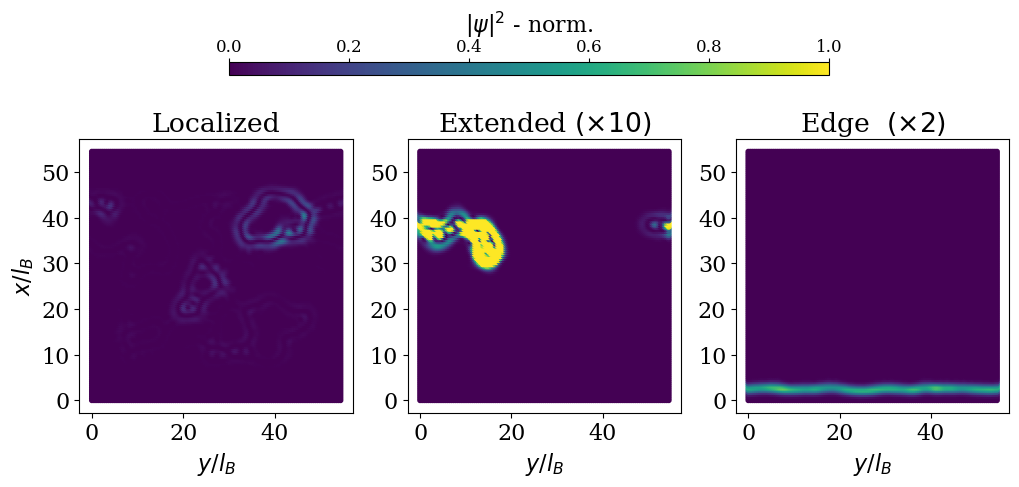

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

positions = np.array([site.pos for site in sys.sites])
x = positions[:, 0]/lB
y = positions[:, 1]/lB

f1 = np.abs(evecs[:, ntarg1])**2
f2 = np.abs(evecs[:, ntarg2])**2
f3 = np.abs(evecs[:, ntarg3])**2

vmin = 0
vmax = max(f1.max(), f2.max(), f3.max())/2

fig = plt.figure(figsize=(12, 4.5))

# 2 rows: colorbar (thin) + panels
gs = GridSpec(
    2, 3,
    height_ratios=[0.02, .5],
    hspace=0.15,
    figure=fig
)

# colorbar axis (spans all columns)
cax = fig.add_subplot(gs[0, :])

# panel axes
axes = [fig.add_subplot(gs[1, i]) for i in range(3)]

for ax, f, title in zip(
    axes,
    [f1/vmax, 10*f2/vmax, 2*f3/vmax],
    [r"Localized", r"Extended $(\times 10)$", r"Edge  $(\times 2)$"]
):
    sc = ax.scatter(
        y, x,
        c=f,
        s=10,
        vmin=vmin,
        vmax=1,
        cmap="viridis"
    )
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$y / l_B$", fontdict=font)

axes[0].set_ylabel(r"$x /l_B$",  fontdict=font)

# horizontal colorbar ABOVE everything
cbar = fig.colorbar(
    sc,
    cax=cax,
    orientation="horizontal"
)

cbar.ax.set_position([
    0.25,  # left
    0.90,  # bottom
    0.5,   # width
    0.03   # height
])

cbar.ax.tick_params(
    labelsize=12,
    length=3,
    pad=2
)


cbar.set_label(r"$|\psi|^2$ - norm.",  fontdict=font)
cbar.ax.xaxis.set_ticks_position("top")
cbar.ax.xaxis.set_label_position("top")

outfile = "eigenstates_3panel_3.png"

"""fig.savefig(
    outfile,
    dpi=300,              # 300 = journal / high-quality print
    bbox_inches="tight",  # prevents clipping of colorbar & labels
    pad_inches=0.02,      # minimal white margin
)"""
plt.show()

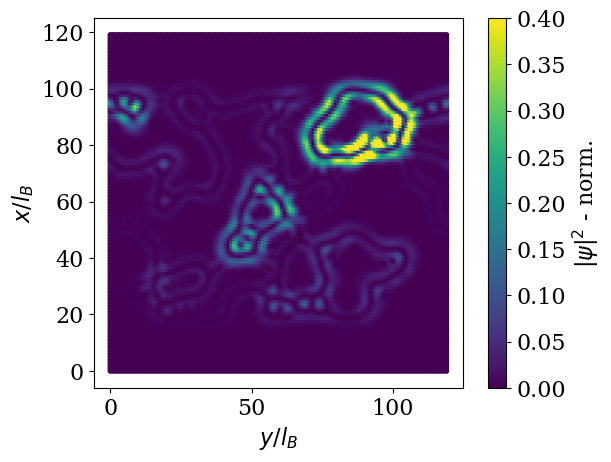

In [19]:
positions = np.array([site.pos for site in sys.sites])
x = positions[:, 0]
y = positions[:, 1]

f1 = np.abs(evecs[:,569])**2

plt.figure()
sc = plt.scatter(y, x, c=f1/np.amax(f1), s=10, vmin=0, vmax=.4)  # add cmap="viridis" if you want
plt.colorbar(sc, label=r"$|\psi|^2$ - norm.")
plt.xlabel(r"$y / l_B$", fontdict=font)
plt.ylabel(r"$x /l_B$",  fontdict=font)
plt.gca().set_aspect("equal", adjustable="box")

#plt.savefig('wavefun_edge9.pdf')

plt.show()